In [15]:
from sklearn.model_selection import train_test_split

In [16]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson')
gdf = gpd.read_file(data_path)

In [17]:
gdf 

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,b_median,b_std,b_var,eccentricity,solidity,mean_intensity,perimeter,compactness,shape_index,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,35863.728720,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,89.0,28.192019,794.789929,0.401669,1.0,63.165356,1331.480192,0.254212,1.983362,"POLYGON ((-72.97056 10.61903, -72.97054 10.619..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,7067.391800,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,91.0,29.475412,868.799885,0.859606,1.0,75.517822,445.486569,0.447507,1.494859,"POLYGON ((-72.96914 10.61884, -72.96915 10.618..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12736.830326,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,62.0,38.685957,1496.603306,0.581758,1.0,57.324478,514.273064,0.605179,1.285459,"POLYGON ((-72.96928 10.61948, -72.96931 10.619..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,20192.843054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,81.0,32.283869,1042.248166,0.609624,1.0,93.691475,578.345347,0.758635,1.148110,"POLYGON ((-72.97264 10.61976, -72.97273 10.619..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5222.807786,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,53.0,27.970275,782.336267,0.571195,1.0,32.228394,459.390754,0.310992,1.793186,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1545.971923,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,55.0,23.200185,538.248594,0.192704,1.0,28.864557,242.379949,0.330688,1.738965,"POLYGON ((-75.123 3.80901, -75.12297 3.809, -7..."
1960,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026303,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,43.5,21.879651,478.719136,0.595796,1.0,0.083861,11.946954,0.002316,20.780311,"POLYGON ((-75.12391 3.81075, -75.1239 3.81076,..."
1961,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10654.442452,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,34.0,26.099047,681.160241,0.225197,1.0,27.726738,1277.998650,0.081975,3.492690,"POLYGON ((-75.12278 3.8104, -75.12282 3.81044,..."
1962,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5196.479151,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,49.0,21.899011,479.566690,0.896007,1.0,44.873081,376.043545,0.461788,1.471562,"POLYGON ((-75.12367 3.81079, -75.12357 3.81077..."


In [18]:
gdf.columns

Index(['CODIGO', 'OBSERV', 'INSUMO', 'APOYO', 'ASIGNACION', 'Asignado', 'OAM',
       'area', 'url_type', 'download_url', 'poly_id', 'image_uid', 'r_mean',
       'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var',
       'b_mean', 'b_median', 'b_std', 'b_var', 'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index',
       'geometry'],
      dtype='object')

In [19]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index','area']
na_count = gdf[features].isna().sum()
print(f"Number of NA values in 'features' column: {na_count}")

Number of NA values in 'features' column: r_mean            35
r_median          35
r_std             35
r_var             35
g_mean            35
g_median          35
g_std             35
g_var             35
b_mean            35
b_median          35
b_var             35
b_std             35
eccentricity      13
solidity          13
mean_intensity    13
perimeter          0
compactness        0
shape_index        0
area               0
dtype: int64


In [20]:
gdf = gdf.dropna(subset=['r_mean'])

In [21]:
print(gdf['CODIGO'].value_counts())

CODIGO
0       665
231     316
311     157
333     144
112     138
233     125
232      64
313      58
22       57
21       42
122      34
511      23
111      17
312      17
512      14
323      14
3212     13
32       10
331       6
334       4
121       4
513       3
3211      3
31        1
Name: count, dtype: int64


/Users/krschap/foss/landcoverclassification/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: xlabel='CODIGO_GROUP'>

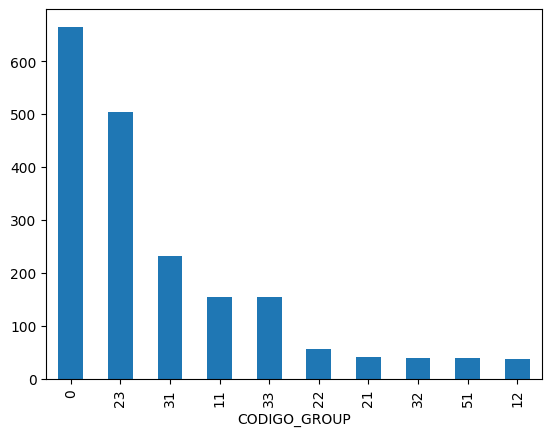

In [22]:
gdf['CODIGO_GROUP'] = gdf['CODIGO'].astype(str).str[:2]
gdf['CODIGO_GROUP'].value_counts().plot(kind='bar')

In [23]:
print(gdf['OBSERV'].value_counts())

OBSERV
building                        665
clean pasture                   316
dense forest                    157
Bare areas                      144
urban not continuous            138
weedy pasture                   125
wooded pasture                   64
fragmented forest                58
permanent crops                  57
seasonal crops                   42
highway                          33
rivers                           23
urban                            17
Open forest                      17
lakes                            14
Secondary vegetation             14
Open grassland                   13
Shrubland                        10
Sandy areas                       6
Burnt areas                       4
comercial or industrial area      4
canals                            3
Dense grassland                   3
forest                            1
Name: count, dtype: int64


### Train Split : 

We will use **stratify** , because we care about the distribution in class , just to make sure the class distribution is there in the test set as well 

train set distribution:
CODIGO_GROUP
0     532
23    404
31    186
11    124
33    123
22     46
21     34
51     32
32     32
12     30
Name: count, dtype: int64

 test distribution:
CODIGO_GROUP
0     133
23    101
31     47
33     31
11     31
22     11
12      8
51      8
32      8
21      8
Name: count, dtype: int64


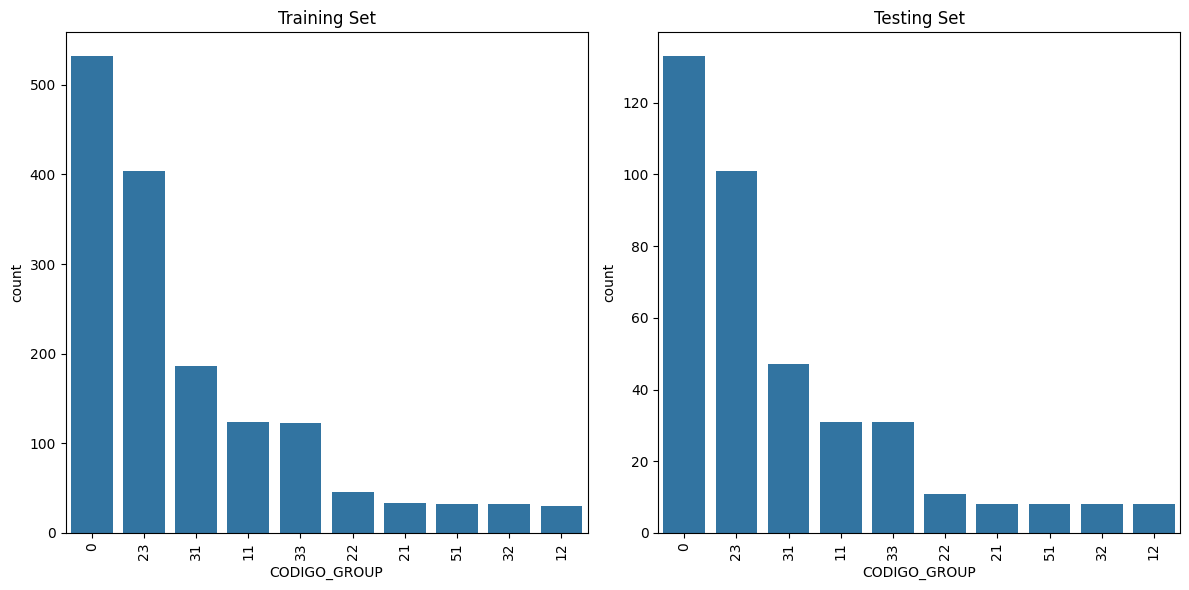

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'CODIGO_GROUP'
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std', 'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index', 'area']

train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[target])

print("train set distribution:")
print(train_gdf[target].value_counts())
print("\n test distribution:")
print(test_gdf[target].value_counts())


class_order = train_gdf[target].value_counts().index

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(x=target, data=train_gdf, ax=ax[0], order=class_order)
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Training Set")

sns.countplot(x=target, data=test_gdf, ax=ax[1], order=class_order)
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Testing Set")

plt.tight_layout()
plt.show()

In [25]:
test_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))
train_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

### Spatially Stratified Sampling ?

We think as there are features spatially correlated , may be worth doing the spatial stratified sampling 

In [26]:
train_gdf[features]

,r_mean,r_median,r_std,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,b_var,b_std,eccentricity,solidity,mean_intensity,perimeter,compactness,shape_index,area
89,133.839225,143.0,59.441565,3533.299693,126.577544,131.0,44.413079,1972.521559,94.983296,99.0,2067.943114,45.474643,0.524276,1.0,34.753716,9534.024959,0.006733,12.186658,48704.992808
396,114.827518,119.0,64.722609,4189.016147,128.036882,129.0,65.329558,4267.951132,117.081532,107.0,6591.027328,81.185142,0.845097,1.0,84.670380,46.452636,0.609611,1.280777,104.680054
1011,133.370506,135.0,65.046095,4230.994463,137.986885,140.0,54.743420,2996.842014,104.468104,99.0,3807.557075,61.705406,0.881528,1.0,74.835030,589.182110,0.363017,1.659727,10028.035637
1052,107.629064,101.0,64.980378,4222.449467,117.243460,115.0,60.172319,3620.707985,83.409694,72.0,2844.281551,53.331806,0.895649,1.0,16.968140,436.707348,0.140868,2.664368,2137.877041
1043,92.971167,85.0,59.308390,3517.485171,108.644764,100.0,58.166377,3383.327388,57.937371,46.0,1600.675768,40.008446,0.524446,1.0,56.339184,263.186011,0.715069,1.182568,3941.519914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,206.543019,236.0,58.454599,3416.940109,219.875190,247.0,53.746206,2888.654662,214.689229,249.0,4194.572925,64.765523,0.783809,1.0,185.243057,20.575827,0.737560,1.164398,24.848614
664,126.569305,123.0,39.021389,1522.668775,132.139372,133.0,31.927362,1019.356443,89.507846,87.0,805.608281,28.383239,0.627019,1.0,70.136940,69.244661,0.729419,1.170878,278.316951
766,155.889617,157.0,50.859625,2586.701480,158.537087,157.0,41.192116,1696.790387,108.309472,92.0,3088.117043,55.570829,0.428916,1.0,72.395096,62.793379,0.482874,1.439074,151.513593
1630,138.203282,139.0,28.928396,836.852124,154.403635,157.0,29.309477,859.045420,104.790897,104.0,451.728322,21.253901,0.320450,1.0,68.648422,256.573661,0.555034,1.342271,2907.593573


In [27]:
test_gdf[features]

,r_mean,r_median,r_std,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,b_var,b_std,eccentricity,solidity,mean_intensity,perimeter,compactness,shape_index,area
189,209.842108,235.0,56.405235,3181.550505,215.251759,246.0,58.857142,3464.163108,217.176922,251.0,3672.077877,60.597672,0.000000,1.000000,175.079742,16.487321,0.780406,1.131982,16.881504
972,172.106141,180.0,35.726801,1276.404315,189.003401,204.0,35.625265,1269.159521,189.531541,210.0,1709.376901,41.344612,0.495261,1.000000,128.606705,25.607665,0.779435,1.132687,40.673357
1176,169.186053,204.0,71.615130,5128.726872,164.075252,182.0,64.124714,4111.978974,165.477083,188.0,4482.021223,66.947899,0.792294,1.000000,71.321175,198.648640,0.190437,2.291526,598.014800
1852,129.676551,140.0,38.733380,1500.274735,118.839881,129.0,42.042603,1767.580439,109.303006,113.0,2281.023361,47.760060,0.271866,1.000000,60.813080,54.356640,0.803992,1.115255,189.037070
1552,115.953335,118.0,29.588005,875.450013,141.329024,144.0,28.595190,817.684864,92.193392,91.0,519.136737,22.784572,0.958863,1.000000,46.917938,518.845698,0.271164,1.920366,5808.962255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,107.434949,108.0,21.107432,445.523681,116.910780,118.0,19.493799,380.008213,67.237877,67.0,367.670810,19.174744,0.925356,0.359334,97.168274,4309.851658,0.125202,2.826148,185065.347794
969,117.314502,120.0,42.670445,1820.766899,143.325772,145.0,38.494051,1481.791956,94.154177,96.0,1372.387109,37.045743,0.522821,1.000000,87.586967,173.438804,0.694754,1.199732,1663.082843
1391,92.411471,90.0,33.098067,1095.482064,111.421890,110.0,35.216636,1240.211483,46.496738,43.0,669.961740,25.883619,0.788938,0.974010,81.377350,124.455752,0.768540,1.140687,947.298318
1752,159.629191,168.0,52.557811,2762.323524,145.039956,151.0,57.068602,3256.825280,136.702180,136.0,3938.518294,62.757615,0.785495,0.780516,147.641525,101.741567,0.472270,1.455141,389.024538
